Check real BEAM-T dataset
Estimate parameters for simulation
Check if simulation makes sense

In [1]:
import pandas as pd
import seaborn as sns
import os
import warnings
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import muon as mu
import scirpy as ir
import scanpy as sc
from mudata import MuData
from sklearn.metrics import roc_auc_score
import numpyro.distributions as npd
import jax
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import truncnorm


warnings.catch_warnings()
warnings.simplefilter("ignore")

pd.set_option('display.max_columns', 1000)

In [2]:
%load_ext autoreload
%autoreload 2

# Estimate simulation parameters from real data (BEAM-T)

In [3]:
# Preprocessing
experiment = '10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein'
if not os.path.exists(f'../../data/BEAMT/{experiment}/preprocessed.h5mu'):
    adata_tcr = ir.io.read_10x_vdj(
        f"../../data/BEAMT/{experiment}/filtered_contig_annotations.csv")

    adata = sc.read_10x_h5(
        f"../../data/BEAMT/{experiment}/sample_filtered_feature_bc_matrix.h5",
        gex_only=False)
    adata.var_names_make_unique()
    mdata = mu.MuData({"gex": adata, "airr": adata_tcr})
    ir.pp.index_chains(mdata)
    ir.tl.chain_qc(mdata)

    # filter TCRs only and antigen barcodes only
    mdata = mdata[mdata.obs["airr:receptor_type"] == "TCR"]
    mdata = mdata[:, mdata.var["gex:feature_types"] == "Antigen Capture"]

    # minimal pMHC QC filtering
    sc.pp.filter_cells(mdata["gex"], min_genes=1)
    sc.pp.filter_genes(mdata["gex"], min_cells=10)

    mdata.update()

    mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))
    mu.pp.intersect_obs(mdata)

    ir.pp.ir_dist(mdata)  # Adds clone_id
    ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
    
    ir.pp.ir_dist(mdata, metric="alignment", sequence="aa", cutoff=250)
    ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="alignment", receptor_arms="all",
                                    dual_ir="primary_only")  # Used for distance calculation
    ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="alignment")

    dist = mdata.mod["airr"].uns["cc_aa_alignment"]["distances"].toarray()
    mdata.mod["airr"].uns["ir_dist_aa_full"] = dist - 1

    mdata.write(f'../../data/BEAMT/{experiment}/preprocessed.h5mu', compression='gzip')

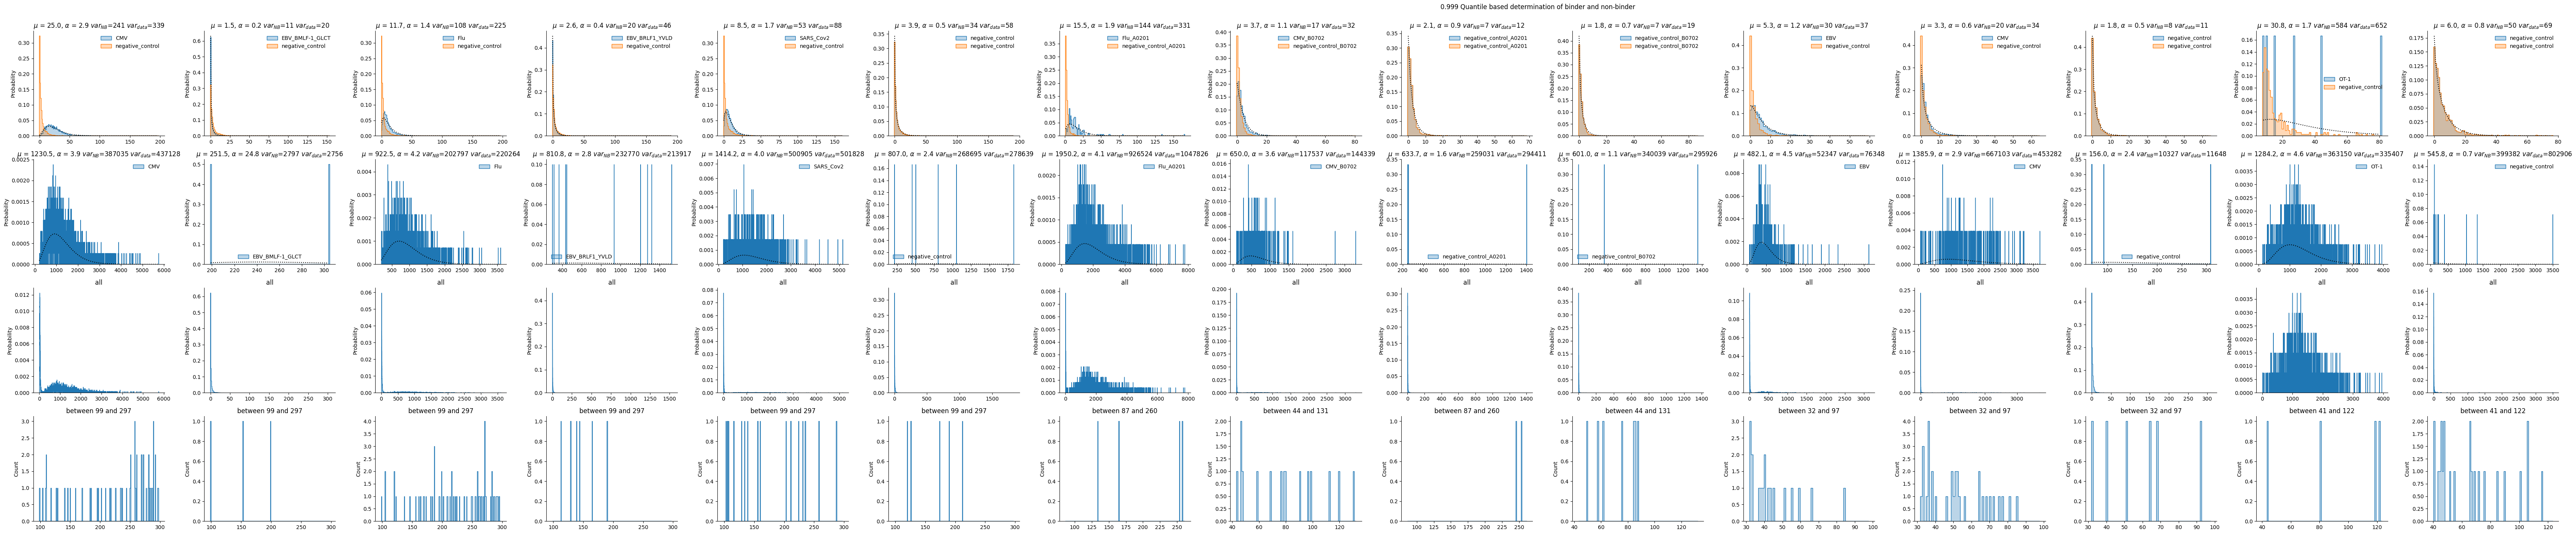

,file,gene,threshold,mean_neg,concentration_neg,var_nb_neg,var_data_neg,mean-,concentration-,var_nb-,var_data-,std_nb-,std_data-,overdisp_nb-,overdisp_data-,cof_var_nb-,cof_var_data-,N-,mean+,concentration+,var_nb+,var_data+,std_nb+,std_data+,overdisp_nb+,overdisp_data+,cof_var_nb+,cof_var_data+,N+,mean_ratio,concentration_ratio,var_nb_ratio,var_data_ratio,overdisp_nb_ratio,overdisp_data_ratio,N_ratio,binder_ratio,noise_to_neg_mean
0,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,CMV,197.942,4.722340,3.939271e-01,61.333071,1039.818115,25.003214,2.897500,240.761868,338.704865,15.516503,18.403936,9.629237,13.546453,0.620580,0.736063,1867,1230.471773,3.924429,387034.531887,4.371280e+05,622.120995,661.156539,314.541577,355.252334,0.505596,0.537320,3773,49.212545,1.354419,1607.540828,1290.586670,32.665265,26.224749,2.020889,0.668972,5.294666
1,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,EBV_BMLF-1_GLCT,197.942,4.722340,3.939271e-01,61.333071,1039.818115,1.454062,0.231539,10.585553,20.490885,3.253545,4.526686,7.279988,14.092170,2.237556,3.113132,5638,251.500000,24.847288,2797.139942,2.756250e+03,52.887994,52.500000,11.121829,10.959245,0.210290,0.208748,2,172.963772,107.313660,264.241278,134.511032,1.527726,0.777683,0.000355,0.000355,0.307911
2,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,Flu,197.942,4.722340,3.939271e-01,61.333071,1039.818115,11.730760,1.432491,107.794731,224.974823,10.382424,14.999161,9.189066,19.178196,0.885060,1.278618,4249,922.462976,4.215191,202796.575052,2.202642e+05,450.329407,469.323150,219.842509,238.778384,0.488182,0.508772,1391,78.636249,2.942561,1881.321785,979.061646,23.924358,12.450513,0.327371,0.246631,2.484099
3,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,EBV_BRLF1_YVLD,197.942,4.722340,3.939271e-01,61.333071,1039.818115,2.596270,0.386810,20.022444,45.894730,4.474645,6.774565,7.712004,17.677179,1.723490,2.609345,5630,810.800000,2.834109,232769.662520,2.139172e+05,482.462084,462.511790,287.086412,263.834677,0.595045,0.570439,10,312.294178,7.326876,11625.436849,4661.039551,37.225916,14.925157,0.001776,0.001773,0.549785
4,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,SARS_Cov2,197.942,4.722340,3.939271e-01,61.333071,1039.818115,8.543229,1.653138,52.693679,87.826508,7.259041,9.371580,6.167888,10.280247,0.849684,1.096960,5066,1414.221254,4.004123,500904.754996,5.018279e+05,707.746250,708.398127,354.191223,354.843985,0.500449,0.500910,574,165.537081,2.422136,9505.974155,5713.854980,57.425044,34.517068,0.113304,0.101773,1.809109
5,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,negative_control,197.942,4.722340,3.939271e-01,61.333071,1039.818115,3.867945,0.489523,34.430371,57.992855,5.867740,7.615304,8.901464,14.993197,1.517018,1.968824,5634,807.000000,2.431045,268695.473466,2.786387e+05,518.358441,527.862346,332.955977,345.277145,0.642328,0.654105,6,208.637941,4.966156,7804.024882,4804.706543,37.404630,23.028921,0.001065,0.001064,0.819074
6,5k_BEAM-T_Human_A0201_B0702_PBMC,Flu_A0201,173.376,2.901204,2.628828e+32,2.901204,875.116882,15.505495,1.876203,143.647475,331.107086,11.985302,18.196348,9.264295,21.354178,0.772971,1.173542,182,1950.187696,4.113499,926523.693207,1.047826e+06,962.561008,1023.633510,475.094625,537.294725,0.493574,0.524890,2227,125.773976,2.192459,6449.982473,3164.612305,51.282329,25.161106,12.236264,0.924450,5.344504
7,5k_BEAM-T_Human_A0201_B0702_PBMC,CMV_B0702,87.184,2.528850,8.153597e+11,2.528850,833.862305,3.732883,1.053218,16.963204,32.455223,4.118641,5.696949,4.544264,8.694412,1.103341,1.526153,2220,649.994709,3.614533,117537.315045,1.443395e+05,342.837155,379.920325,180.828110,222.062505,0.527446,0.584498,189,174.126735,3.431894,6928.957342,4447.341309,39.792610,25.540830,0.085135,0.078456,1.476119
8,5k_BEAM-T_Human_A0201_B0702_PBMC,negative_control_A0201,173.376,2.901204,2.628828e+32,2.901204,875.116882,2.114713,0.873756,7.232860,12.402468,2.689398,3.521714,3.420256,5.864846,1.271755,1.665339,2406,633.666667,1.553935,259031.426601,2.944109e+05,508.951301,542.596449,408.781841,464.6147

In [4]:
# Determine params based on negative control percentile threshold for all BEAM-T datasets and all genes
QUANTILE = 0.999
FILES = ['10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein', '5k_BEAM-T_Human_A0201_B0702_PBMC', '10k_BEAM-T_Human_A2402_EBV_CMV_spikein', '2k_BEAM-T_Mouse_H2Kb_OT-1_5pv2']  #  '10k_BEAM-T_Human_A1101_EBV_spikein', 

params = []
nrows = 4
ncols = 18
plt.figure(figsize=(4.5 * ncols, 3.5 * nrows))
i = 0
for file in FILES:
    mdata = mu.read(f'../../data/BEAMT/{file}/preprocessed.h5mu')
    genes = mdata.var['gex:gene_ids'].unique()
    for gene in genes:
        if file == '5k_BEAM-T_Human_A0201_B0702_PBMC':  # Has two negative controls
            mhc = gene.split('_')[-1]
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene and mhc in gene][0]
        else:
            neg_ctrl_key = [gene for gene in mdata.var['gex:gene_ids'].unique() if 'negative' in gene][0]
        x_neg = mdata['gex'][:, neg_ctrl_key].X.toarray().reshape(-1, )
        nbfit_neg = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_neg})).fit(disp=False)
        mean_neg = np.exp(nbfit_neg.params.iloc[0])
        concentration_neg = 1 / nbfit_neg.params.iloc[1]
        var_nb_neg = mean_neg + mean_neg ** 2 / concentration_neg
        var_data_neg = x_neg.var()

        thr = np.quantile(x_neg, QUANTILE) if file != '2k_BEAM-T_Mouse_H2Kb_OT-1_5pv2' else np.quantile(x_neg, 0.99 )  # 2k only 1339 samples
        x = mdata['gex'][:, gene].X.toarray().reshape(-1, )
        i += 1
        param = {'file': file, 'gene': gene, 'threshold': thr,
				 f'mean_neg': mean_neg, f'concentration_neg': concentration_neg,
				 f'var_nb_neg': var_nb_neg, 'var_data_neg': var_data_neg}

        for direction in ['-', '+']:
            plt.subplot(nrows, ncols, i + (ncols if direction == '+' else 0))
            x_in_threshold = x[x > thr] if direction == '+' else x[x <= thr]
            nbfit = smf.negativebinomial("nbdata ~ 1", data=pd.DataFrame({"nbdata": x_in_threshold})).fit(disp=False)
            mean = np.exp(nbfit.params.iloc[0])
            concentration = 1 / nbfit.params.iloc[1]
            var_nb = mean + mean ** 2 / concentration
            var_data = x_in_threshold.var()
            sns.histplot(x_in_threshold, discrete=True, binrange=(x_in_threshold.min(), x_in_threshold.max()), stat='probability', element='step', fill=True, alpha=0.3, label=gene)
            if direction == '-':
                sns.histplot(x_neg, discrete=True, binrange=(x_in_threshold.min(), x_in_threshold.max()), stat='probability', element='step', fill=True, alpha=0.3, label=neg_ctrl_key)

			# Fitted distribution for visualization
            x_range = np.arange(x_in_threshold.min(), x_in_threshold.max())
            prob = np.exp(npd.NegativeBinomial2(mean, concentration).log_prob(x_range))
            prob = prob / prob.sum()
            sns.lineplot(x=x_range, y=prob, c='black', ls=':')

            plt.legend(frameon=False)
            sns.despine()
            plt.title(r'$\mu$ = {:.1f}, $\alpha$ = {:.1f} $var_{{NB}}$={:.0f} $var_{{data}}$={:.0f}'.format(mean, concentration, var_nb, var_data))
            
            param.update({f'mean{direction}': mean, f'concentration{direction}': concentration, 
                          f'var_nb{direction}': var_nb, f'var_data{direction}': var_data, 
                          f'std_nb{direction}': var_nb ** 0.5, f'std_data{direction}': var_data ** 0.5, 
                          f'overdisp_nb{direction}': var_nb / mean, f'overdisp_data{direction}': var_data / mean, 
                          f'cof_var_nb{direction}': var_nb ** 0.5 / mean, f'cof_var_data{direction}': var_data ** 0.5 / mean, 
                          f'N{direction}': x_in_threshold.shape[0],})

        # Signal and noise
        plt.subplot(nrows, ncols, i + (2 * ncols))
        sns.histplot(x, discrete=True, stat='probability', element='step', fill=True, alpha=0.3, label=gene)
        sns.despine()
        plt.title('all')

        # Close to threshold
        plt.subplot(nrows, ncols, i + (3 * ncols))
        sns.histplot(x, binrange=(thr - thr/2, thr + thr/2), discrete=True, stat='count', element='step', fill=True, alpha=0.3, label=gene)
        sns.despine()
        plt.title(f'between {thr - thr/2:.0f} and {thr + thr/2:.0f}')
        
        params.append(param)
            
plt.suptitle(f'{QUANTILE} Quantile based determination of binder and non-binder', y=1.0)
plt.tight_layout()

plt.show()

params = pd.DataFrame(params)
for key in [f'mean', f'concentration', f'var_nb', f'var_data', f'overdisp_nb', f'overdisp_data', f'N']:
    params[f'{key}_ratio'] = params[f'{key}+'] / params[f'{key}-']
params['binder_ratio'] = params['N+'] / (params['N-'] + params['N+'])
params['noise_to_neg_mean'] = params['mean-'] / params['mean_neg']
params

## Negative control distribution

In [5]:
neg_ctrl_params = params[params['gene'].str.contains('negative')].copy()
neg_ctrl_params[['mean-', 'concentration-', 'var_nb-', 'std_nb-', 'overdisp_nb-', 'cof_var_nb-', 'N-']]

,mean-,concentration-,var_nb-,std_nb-,overdisp_nb-,cof_var_nb-,N-
5,3.867945,0.489523,34.430371,5.867740,8.901464,1.517018,5634
8,2.114713,0.873756,7.232860,2.689398,3.420256,1.271755,2406
9,1.782627,0.662888,6.576434,2.564456,3.689182,1.438583,2406
12,1.801178,0.549719,7.702813,2.775394,4.276543,1.540878,2887
14,5.961509,0.812680,49.692846,7.049315,8.335615,1.182472,1325


Truncated log-normal params:  -1.0539178917389445 1.8375518345106903 1.018115879390079 0.4175162931163312


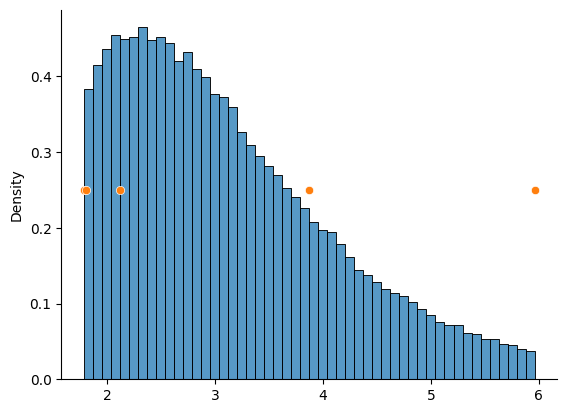

Overdispersion Gamma shape, scale 4.186062616134899 1.2384303396204106


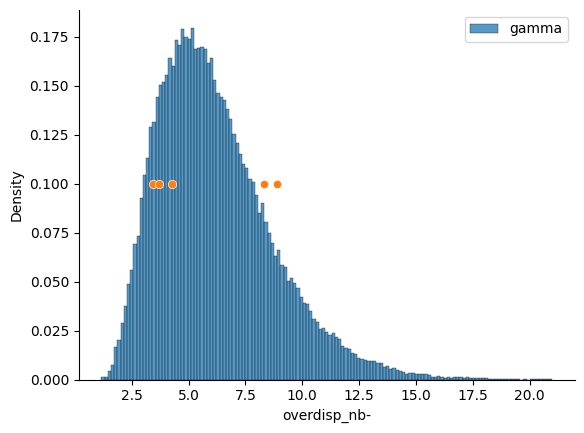

In [6]:
# Parameterize negative control MEAN with, gamma matching first and second moment
# ns    = neg_ctrl_params['N-']      # matching sample sizes

# weights = ns / ns.sum()
# mu_hat  = np.sum(weights * means)
# var_hat = np.sum(weights * (means - mu_hat)**2)

# alpha = mu_hat**2 / var_hat
# theta = var_hat / mu_hat      # scale ; rate = 1/theta

# print(f"Mean shape, scale: {alpha}, {theta}")
# samples = stats.gamma(a=alpha, scale=theta).rvs(10000)
# print(samples.min())
# sns.histplot(samples, stat='density')
# # sns.histplot(neg_ctrl_params['mean-'], stat='density')
# sns.scatterplot(x=neg_ctrl_params['mean-'], y=0.1)
# sns.despine()
# plt.show()


# Truncated log-normal
ns, means = neg_ctrl_params['N-'].to_numpy(float), neg_ctrl_params['mean-'].to_numpy(float)

# Weighted MoM lognormal params
w = ns / ns.sum()
m = np.sum(w * means)
v = np.sum(w * (means - m)**2)
sigma2 = np.log(1 + v / m**2)
sigma  = np.sqrt(sigma2)
mu_ln  = np.log(m) - 0.5 * sigma2

# Truncate to observed range
low, high = means.min(), means.max()
a, b = (np.log(low) - mu_ln) / sigma, (np.log(high) - mu_ln) / sigma
samples = np.exp(truncnorm(a, b, loc=mu_ln, scale=sigma).rvs(100000, random_state=0))
print(f'Truncated log-normal params: ', a, b, mu_ln, sigma)
# Plot
sns.histplot(samples, stat='density', bins=50)
sns.scatterplot(x=means, y=np.full_like(means, 0.25, dtype=float))
sns.despine()
plt.show()

# Parameterize negative control OVERDISPERSION with, gamma matching first and second moment
overdisp = neg_ctrl_params['overdisp_nb-'] - 1

weights = ns / ns.sum()
mu_hat  = np.sum(weights * overdisp)
var_hat = np.sum(weights * (means - mu_hat)**2)

# mu_hat = overdisp.mean()
# var_hat = overdisp.var()
alpha = mu_hat**2 / var_hat
theta = var_hat / mu_hat      # scale ; rate = 1/theta
print('Overdispersion Gamma shape, scale', alpha, theta)
sns.histplot(stats.gamma(a=alpha, scale=theta).rvs(100000).clip(max=20)+1, stat='density', label='gamma')

sns.scatterplot(x=overdisp+1, y=0.1)
sns.despine()
plt.show()

## Non-binder distribution

In [7]:
params[~params['gene'].str.contains('negative')][['mean-', 'mean_ratio', 'mean+', 'N-', 'N+', ]]

,mean-,mean_ratio,mean+,N-,N+
0,25.003214,49.212545,1230.471773,1867,3773
1,1.454062,172.963772,251.500000,5638,2
2,11.730760,78.636249,922.462976,4249,1391
3,2.596270,312.294178,810.800000,5630,10
4,8.543229,165.537081,1414.221254,5066,574
6,15.505495,125.773976,1950.187696,182,2227
7,3.732883,174.126735,649.994709,2220,189
10,5.349569,90.126625,482.138596,2320,570
11,3.266996,424.225101,1385.941634,2633,257
13,30.833333,41.648426,1284.159790,6,1333


In [8]:
non_binder_params = params[~params['gene'].str.contains('negative')].copy()
non_binder_params = non_binder_params[(non_binder_params['N+'] > 20) & (non_binder_params['N-'] > 20)].copy()
non_binder_params[['mean-', 'mean_ratio', 'mean+', 'N-', 'N+', ]]

,mean-,mean_ratio,mean+,N-,N+
0,25.003214,49.212545,1230.471773,1867,3773
2,11.730760,78.636249,922.462976,4249,1391
4,8.543229,165.537081,1414.221254,5066,574
6,15.505495,125.773976,1950.187696,182,2227
7,3.732883,174.126735,649.994709,2220,189
10,5.349569,90.126625,482.138596,2320,570
11,3.266996,424.225101,1385.941634,2633,257


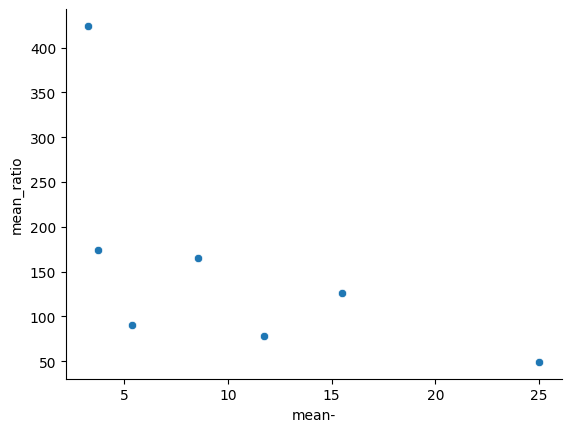

In [9]:
sns.scatterplot(non_binder_params, x='mean-', y='mean_ratio')
sns.despine()
plt.show()

trunc log-normal params for noise:  -1.4325807532116341 1.9485510504360735 2.0461540382126118 0.6019089551720753
lowest sampled value 3.267036725146729


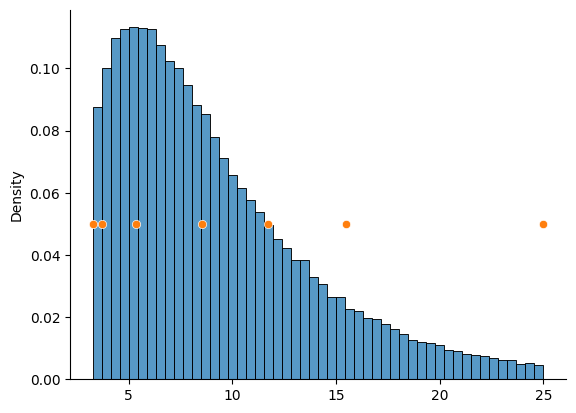

Overdispersion Gamma shape, scale 0.7285976325752553 8.167773103845757


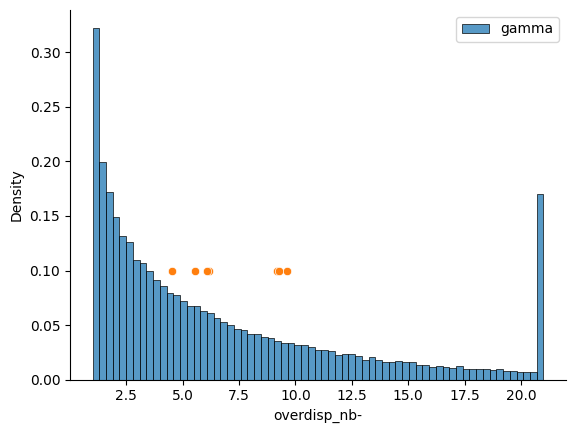

In [10]:
# Parameterize non-binder MEAN with, gamma matching first and second moment
# ns    = non_binder_params['N-']

# weights = ns / ns.sum()
# mu_hat  = np.sum(weights * means)
# var_hat = np.sum(weights * (means - mu_hat)**2)

# alpha = mu_hat**2 / var_hat
# theta = var_hat / mu_hat      # scale ; rate = 1/theta

# print(f"Mean shape, scale: {alpha}, {theta}")
# samples = stats.gamma(a=alpha, scale=theta).rvs(10000)
# print(samples.min())
# sns.histplot(samples, stat='density')
# # sns.histplot(non_binder_params['mean-'], stat='density')
# sns.scatterplot(x=non_binder_params['mean-'], y=0.05)
# sns.despine()
# plt.show()

# Truncated log-normal
non_binder = params[~params['gene'].str.contains('negative', na=False)]
non_binder = non_binder[(non_binder[['N-', 'N+']] > 20).all(1)]
ns, means = non_binder['N-'].to_numpy(float), non_binder['mean-'].to_numpy(float)

# Weighted MoM lognormal params
w = ns / ns.sum()
m = np.sum(w * means)
v = np.sum(w * (means - m)**2)
sigma2 = np.log(1 + v / m**2)
sigma  = np.sqrt(sigma2)
mu_ln  = np.log(m) - 0.5 * sigma2

# Truncate to observed range
low, high = means.min(), means.max()
a, b = (np.log(low) - mu_ln) / sigma, (np.log(high) - mu_ln) / sigma
samples = np.exp(truncnorm(a, b, loc=mu_ln, scale=sigma).rvs(100000, random_state=0))
print('trunc log-normal params for noise: ', a, b, mu_ln, sigma)
print('lowest sampled value', samples.min())
# Plot
sns.histplot(samples, stat='density', bins=50)
sns.scatterplot(x=means, y=np.full_like(means, 0.05, dtype=float))
sns.despine()
plt.show()


# Parameterize non-binder OVERDISPERSION with, gamma matching first and second moment
overdisp = non_binder_params['overdisp_nb-'] - 1

weights = ns / ns.sum()
mu_hat  = np.sum(weights * overdisp)
var_hat = np.sum(weights * (means - mu_hat)**2)

# mu_hat = overdisp.mean()
# var_hat = overdisp.var()
alpha = mu_hat**2 / var_hat
theta = var_hat / mu_hat      # scale ; rate = 1/theta
print('Overdispersion Gamma shape, scale', alpha, theta)
sns.histplot(stats.gamma(a=alpha, scale=theta).rvs(100000).clip(max=20)+1, stat='density', label='gamma')

sns.scatterplot(x=overdisp+1, y=0.1)
sns.despine()
plt.show()

## Mean and Variance fold increase

In [11]:
# Ratio params
ratio_binder_cols = [col for col in params.columns if 'ratio' in col]
ratio_params = params[~params['gene'].str.contains('negative')].copy()
ratio_params = ratio_params[(ratio_params['N-'] > 20) & (ratio_params['N+'] > 20)]
# ratio_params = ratio_params[['file', 'gene', 'threshold'] + non_binder_cols]
ratio_params

,file,gene,threshold,mean_neg,concentration_neg,var_nb_neg,var_data_neg,mean-,concentration-,var_nb-,var_data-,std_nb-,std_data-,overdisp_nb-,overdisp_data-,cof_var_nb-,cof_var_data-,N-,mean+,concentration+,var_nb+,var_data+,std_nb+,std_data+,overdisp_nb+,overdisp_data+,cof_var_nb+,cof_var_data+,N+,mean_ratio,concentration_ratio,var_nb_ratio,var_data_ratio,overdisp_nb_ratio,overdisp_data_ratio,N_ratio,binder_ratio,noise_to_neg_mean
0,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,CMV,197.942,4.722340,3.939271e-01,61.333071,1039.818115,25.003214,2.897500,240.761868,338.704865,15.516503,18.403936,9.629237,13.546453,0.620580,0.736063,1867,1230.471773,3.924429,387034.531887,4.371280e+05,622.120995,661.156539,314.541577,355.252334,0.505596,0.537320,3773,49.212545,1.354419,1607.540828,1290.586670,32.665265,26.224749,2.020889,0.668972,5.294666
2,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,Flu,197.942,4.722340,3.939271e-01,61.333071,1039.818115,11.730760,1.432491,107.794731,224.974823,10.382424,14.999161,9.189066,19.178196,0.885060,1.278618,4249,922.462976,4.215191,202796.575052,2.202642e+05,450.329407,469.323150,219.842509,238.778384,0.488182,0.508772,1391,78.636249,2.942561,1881.321785,979.061646,23.924358,12.450513,0.327371,0.246631,2.484099
4,10k_BEAM-T_Human_A0201_CMV_Flu_Covid_spikein,SARS_Cov2,197.942,4.722340,3.939271e-01,61.333071,1039.818115,8.543229,1.653138,52.693679,87.826508,7.259041,9.371580,6.167888,10.280247,0.849684,1.096960,5066,1414.221254,4.004123,500904.754996,5.018279e+05,707.746250,708.398127,354.191223,354.843985,0.500449,0.500910,574,165.537081,2.422136,9505.974155,5713.854980,57.425044,34.517068,0.113304,0.101773,1.809109
6,5k_BEAM-T_Human_A0201_B0702_PBMC,Flu_A0201,173.376,2.901204,2.628828e+32,2.901204,875.116882,15.505495,1.876203,143.647475,331.107086,11.985302,18.196348,9.264295,21.354178,0.772971,1.173542,182,1950.187696,4.113499,926523.693207,1.047826e+06,962.561008,1023.633510,475.094625,537.294725,0.493574,0.524890,2227,125.773976,2.192459,6449.982473,3164.612305,51.282329,25.161106,12.236264,0.924450,5.344504
7,5k_BEAM-T_Human_A0201_B0702_PBMC,CMV_B0702,87.184,2.528850,8.153597e+11,2.528850,833.862305,3.732883,1.053218,16.963204,32.455223,4.118641,5.696949,4.544264,8.694412,1.103341,1.526153,2220,649.994709,3.614533,117537.315045,1.443395e+05,342.837155,379.920325,180.828110,222.062505,0.527446,0.584498,189,174.126735,3.431894,6928.957342,4447.341309,39.792610,25.540830,0.085135,0.078456,1.476119
10,10k_BEAM-T_Human_A2402_EBV_CMV_spikein,EBV,64.444,1.961246,4.752330e-01,10.055138,47.815094,5.349569,1.177876,29.645753,36.547199,5.444791,6.045428,5.541709,6.831803,1.017800,1.130078,2320,482.138596,4.481992,52346.939110,7.634764e+04,228.794535,276.310768,108.572389,158.352061,0.474541,0.573094,570,90.126625,3.805148,1765.748310,2089.014893,19.591861,23.178665,0.245690,0.197232,2.727638
11,10k_BEAM-T_Human_A2402_EBV_CMV_spikein,CMV,64.444,1.961246,4.752330e-01,10.055138,47.815094,3.266996,0.645879,19.792167,33.713371,4.448839,5.806322,6.058216,10.319380,1.361752,1.777266,2633,1385.941634,2.885361,667102.997951,4.532816e+05,816.763734,673.261929,481.335564,327.056792,0.589320,0.485779,257,424.225101,4.467340,33705.405280,13445.158203,79.451699,31.693454,0.097607,0.088927,1.665776


<Axes: xlabel='mean_ratio', ylabel='Density'>

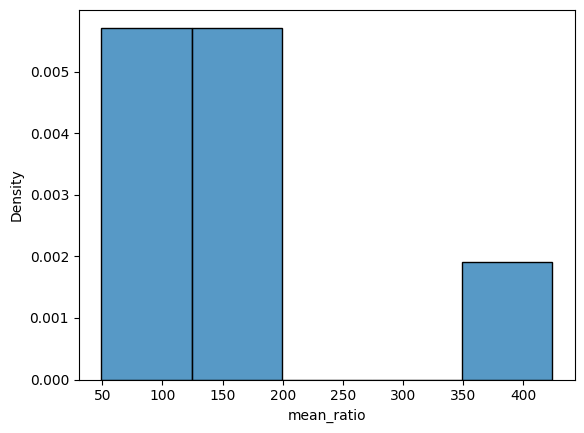

In [12]:
# Mean fold increase (binder count with respect to non-binder)
sns.histplot(ratio_params, x='mean_ratio', stat='density')
# samples = stats.norm(*stats.norm.fit(ratio_params['mean_ratio'])).rvs(size=10000)
# sns.histplot(samples, stat='density')
# sns.scatterplot(ratio_params, x='mean_ratio', y=1)

<Axes: xlabel='mean+', ylabel='Density'>

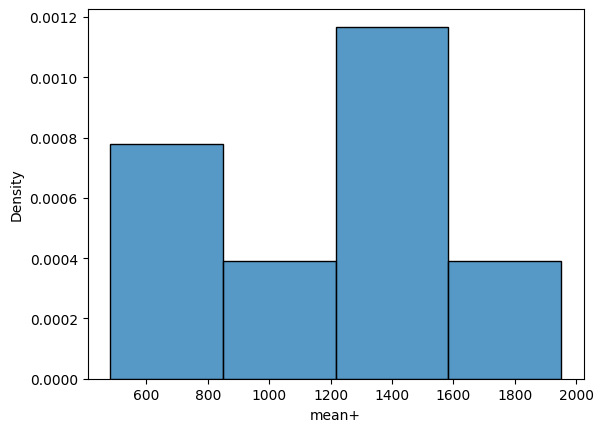

In [13]:
sns.histplot(ratio_params, x='mean+', stat='density')

<Axes: xlabel='overdisp_nb+', ylabel='Count'>

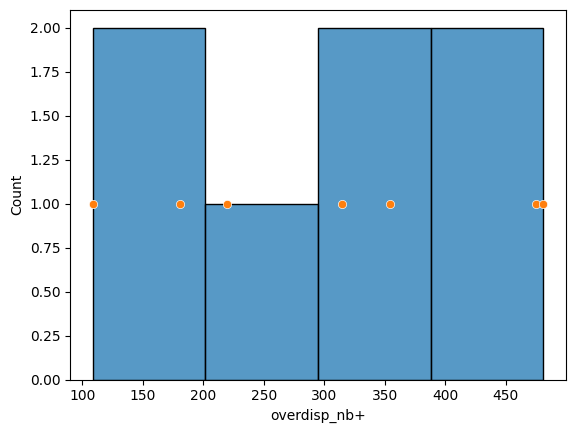

In [14]:
# Var fold increase (with respect to mean, basically overdispersion)
sns.histplot(ratio_params, x='overdisp_nb+')
sns.scatterplot(ratio_params, x='overdisp_nb+', y=1)

<Axes: xlabel='mean-', ylabel='mean_ratio'>

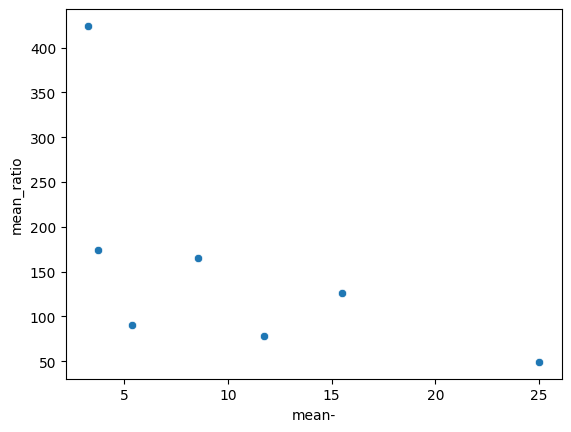

In [15]:
sns.scatterplot(ratio_params, x='mean-', y='mean_ratio')

<Axes: xlabel='mean_ratio', ylabel='overdisp_nb+'>

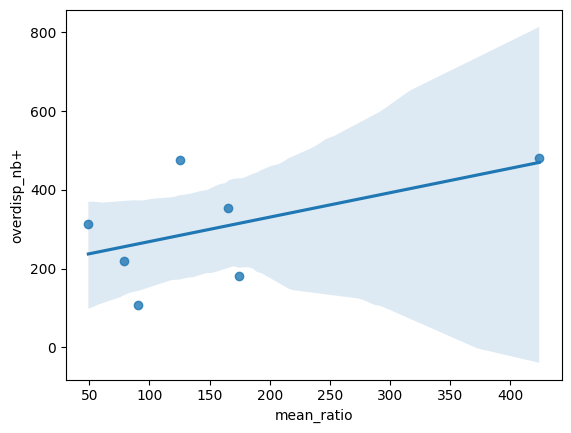

In [16]:
sns.regplot(ratio_params, x='mean_ratio', y='overdisp_nb+')

## Test out new simulator

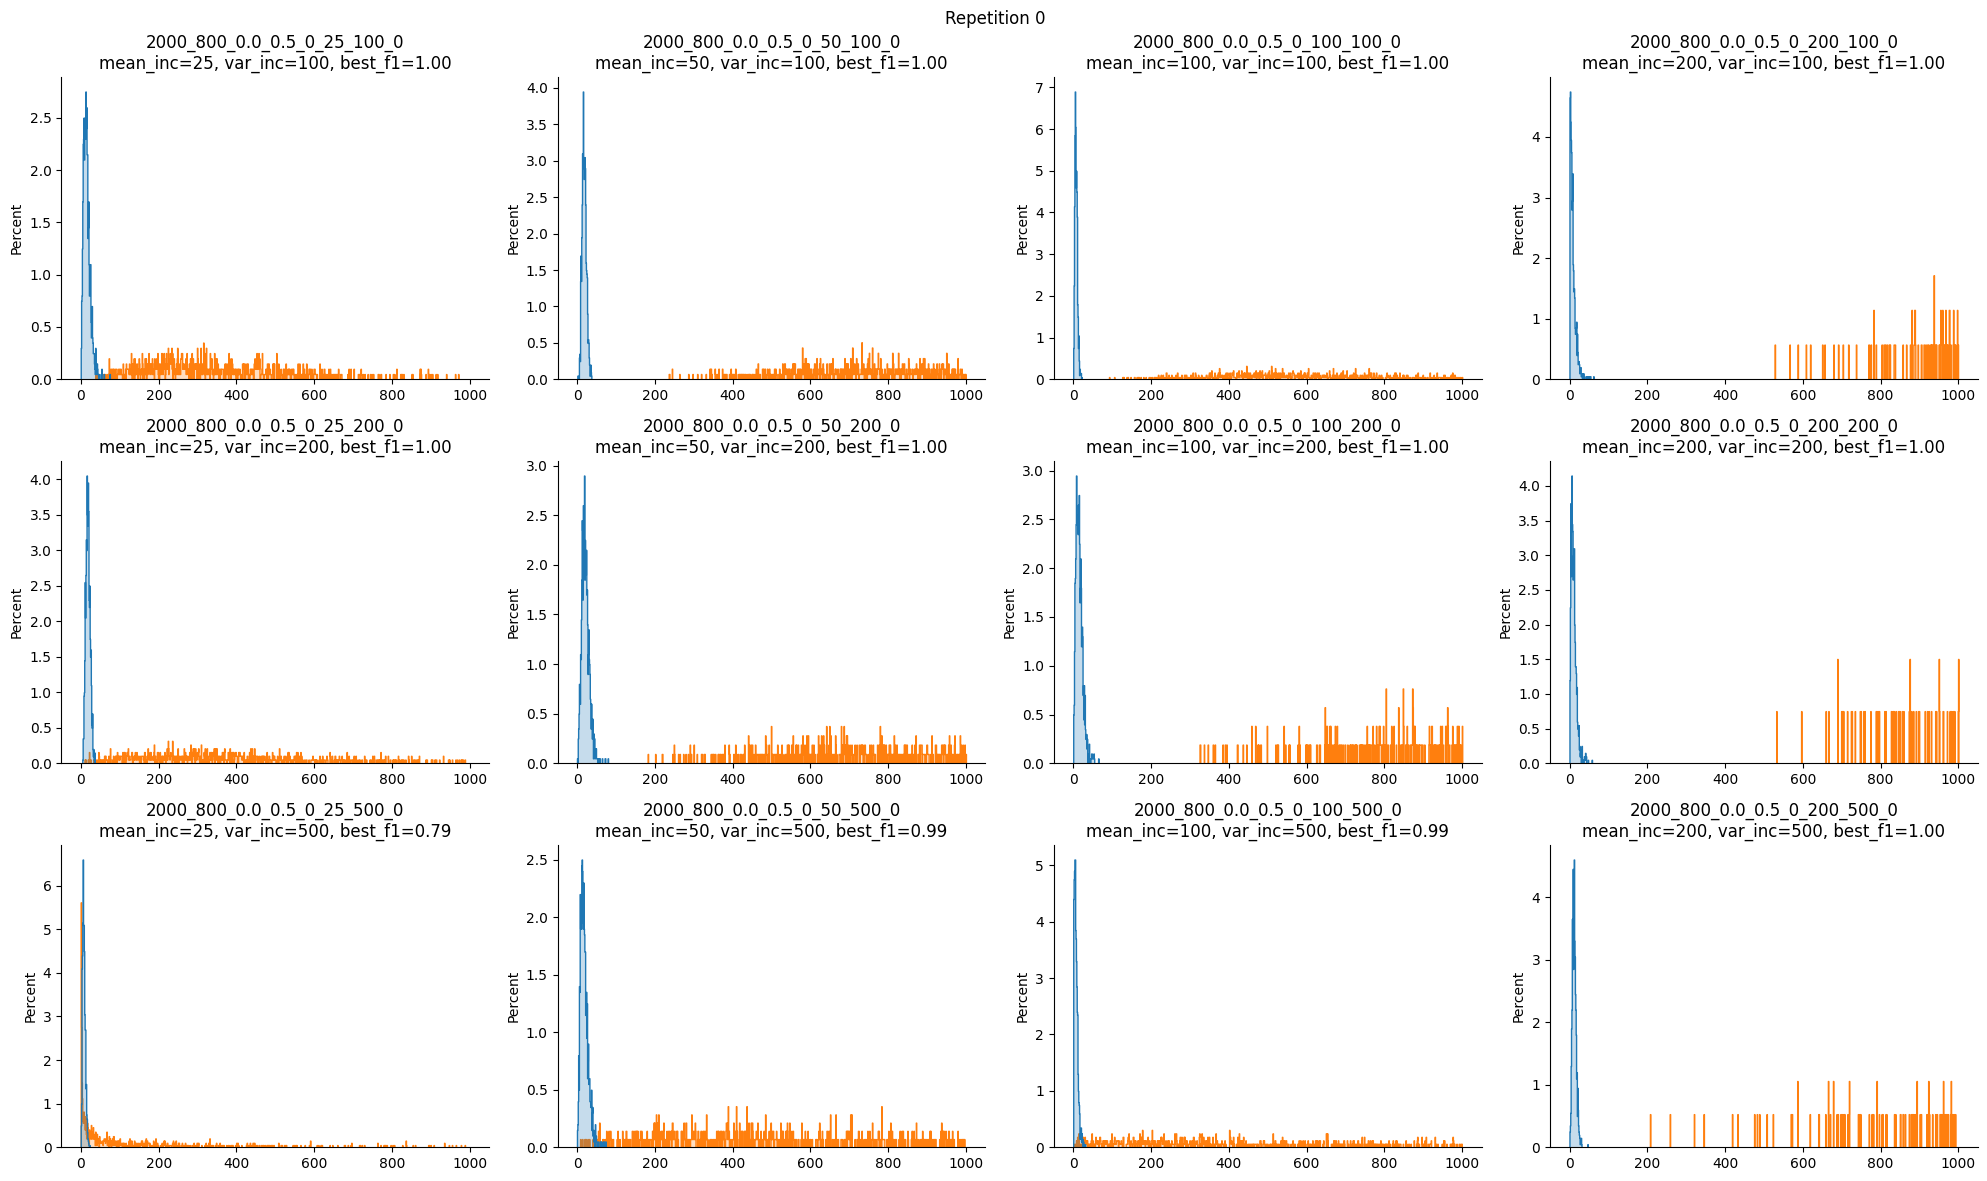

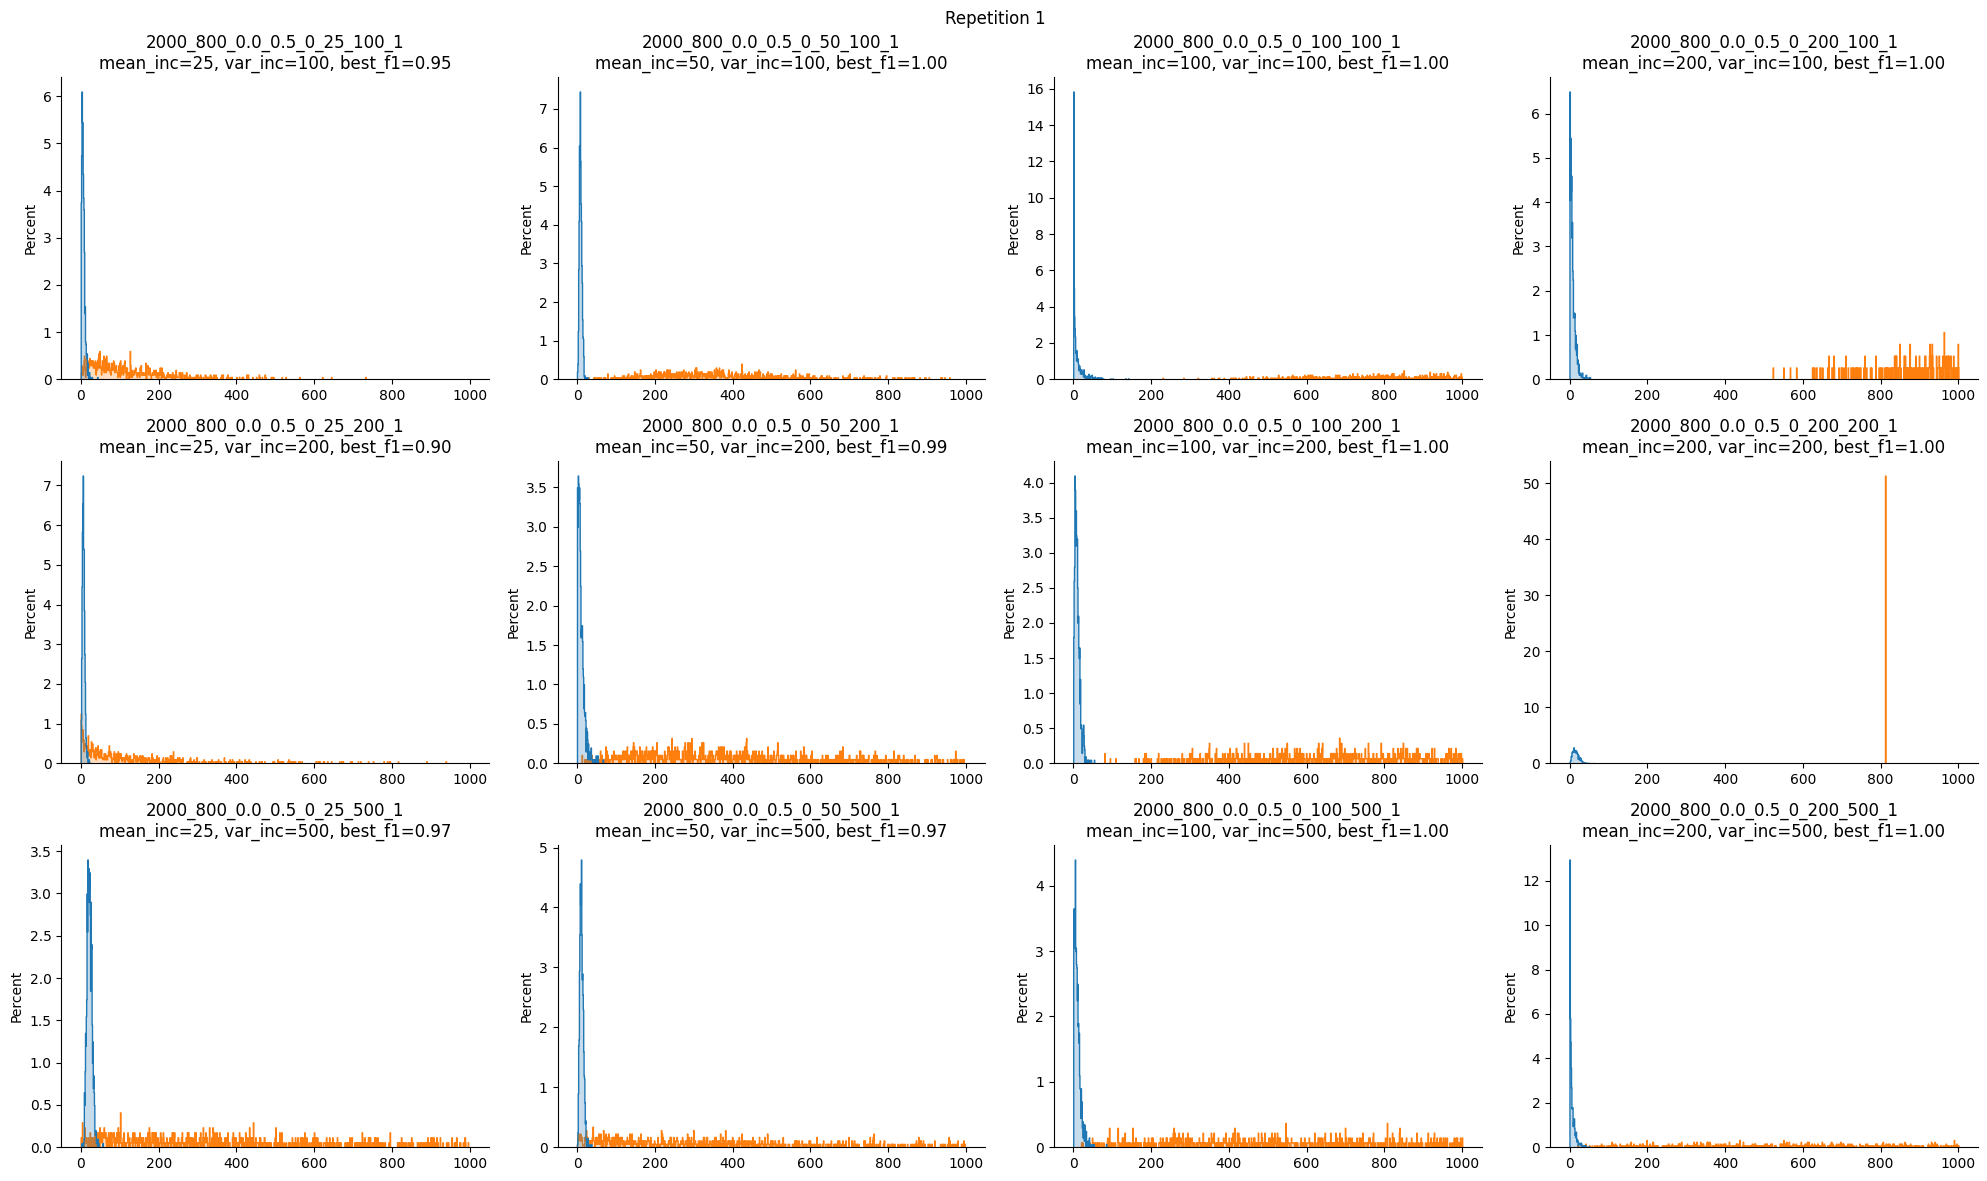

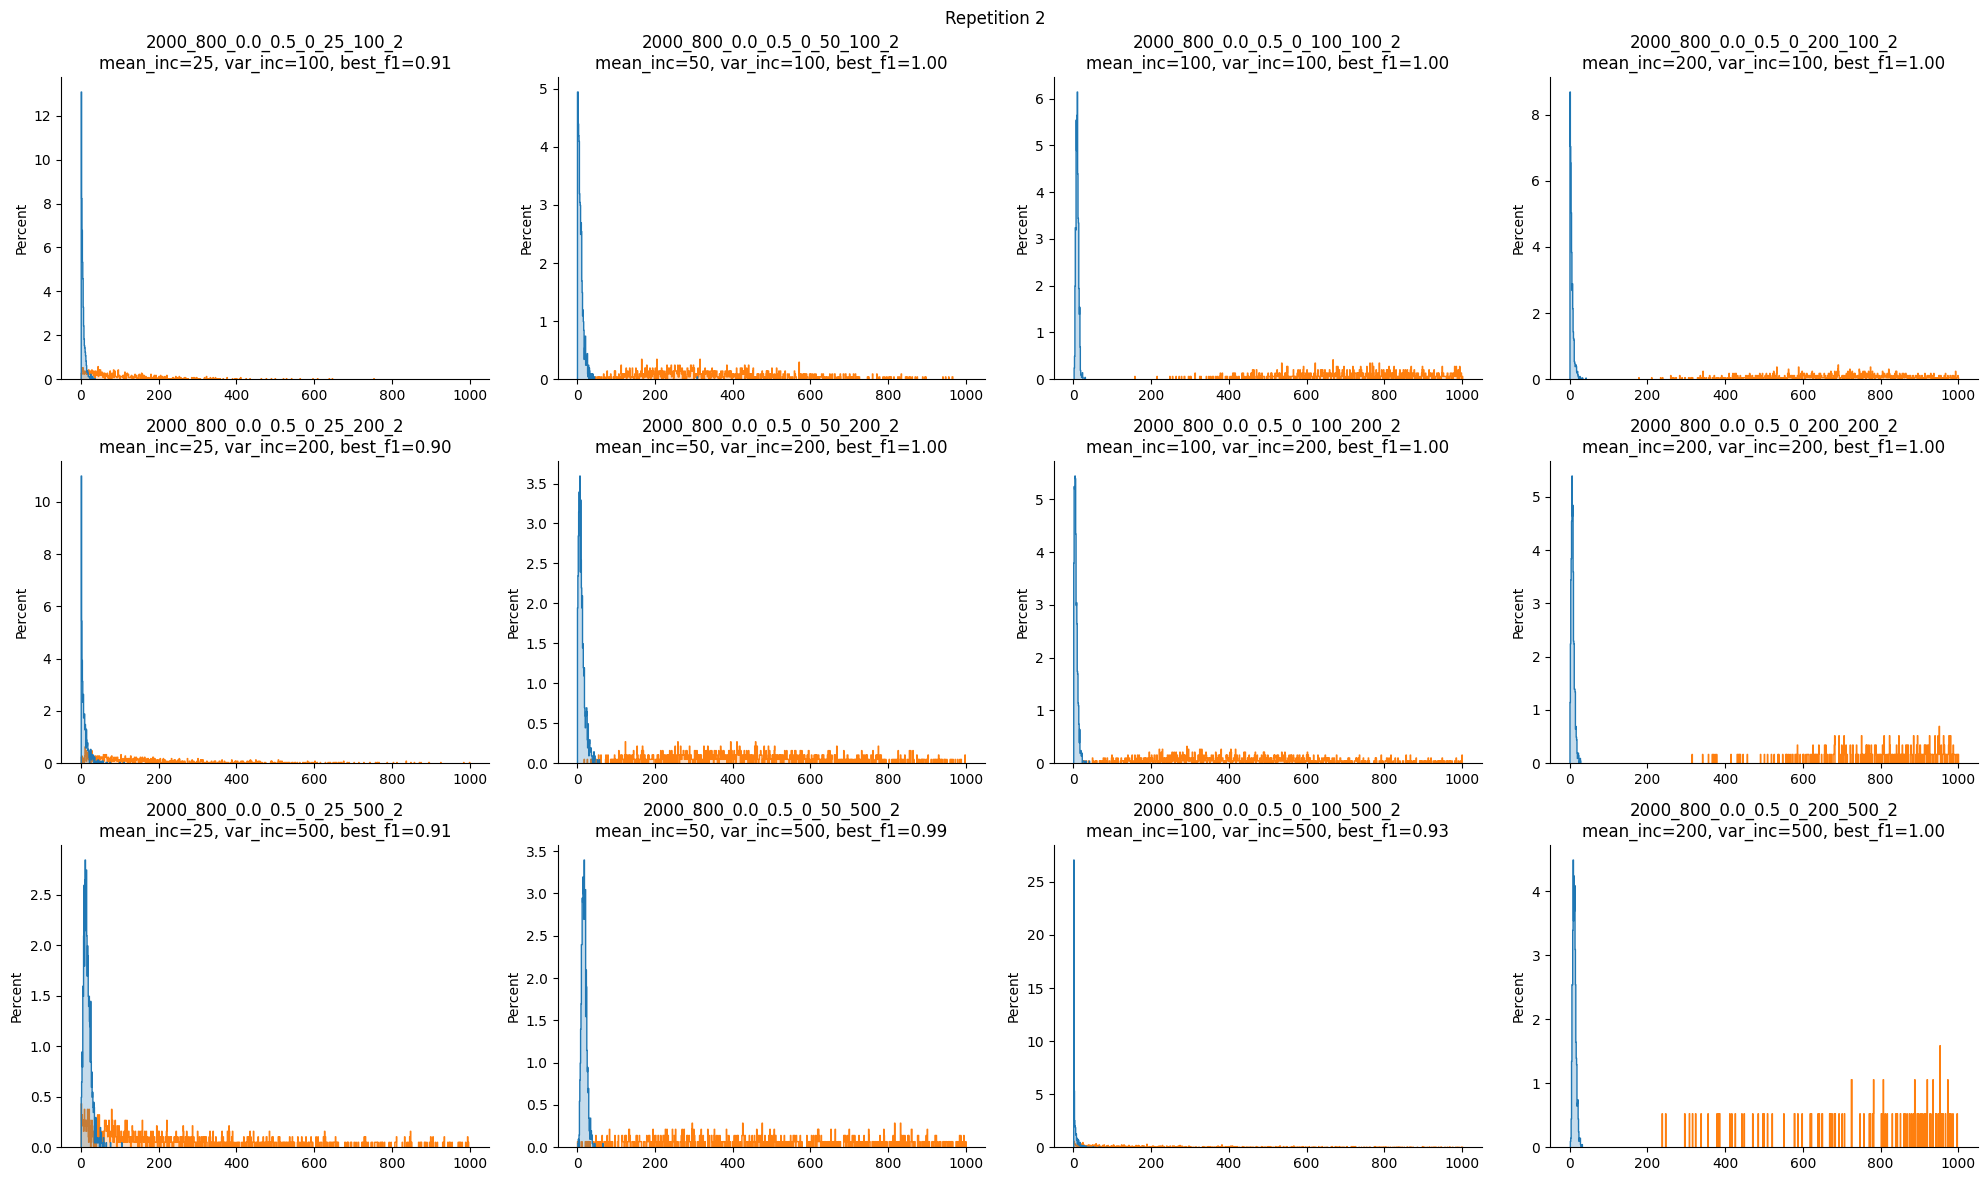

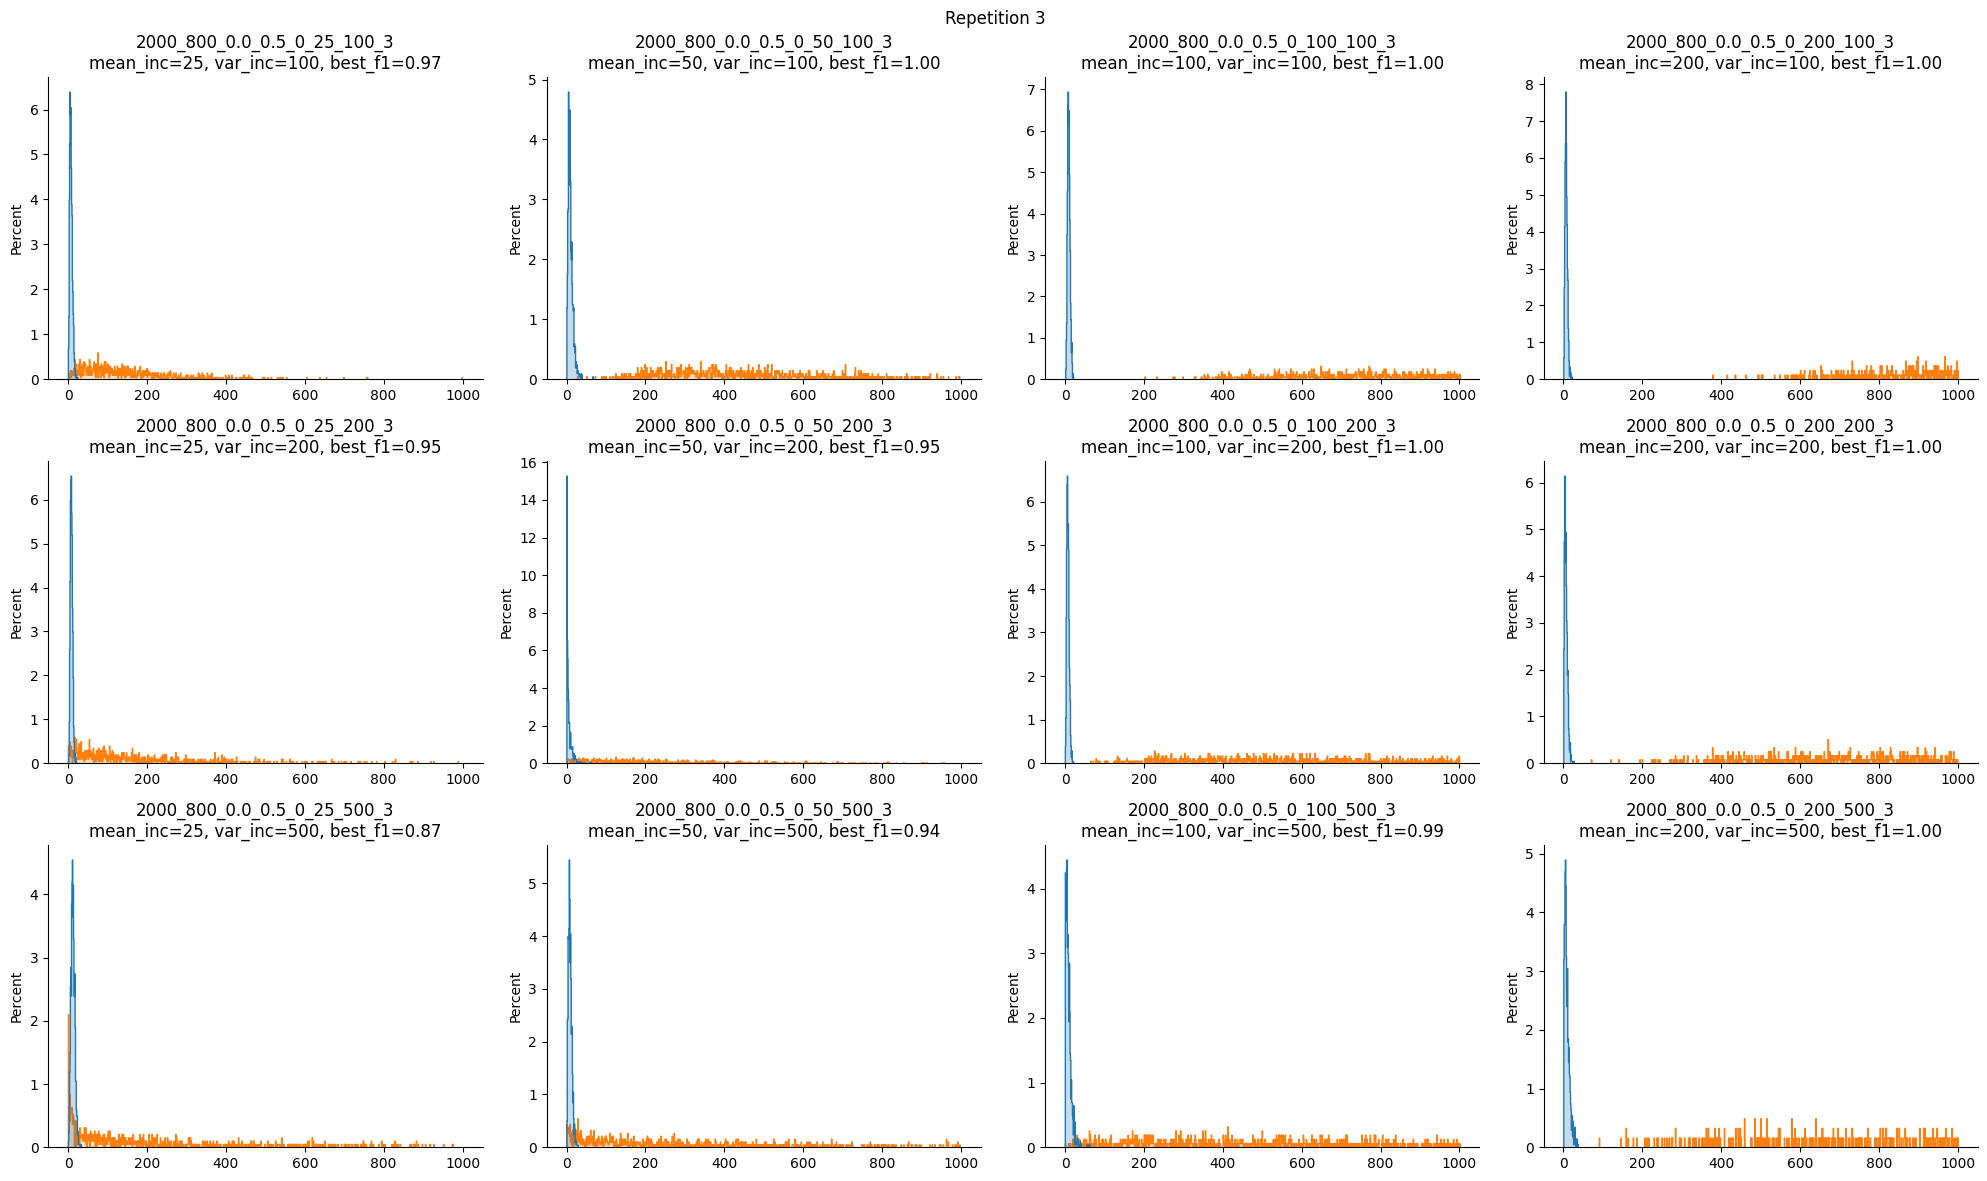

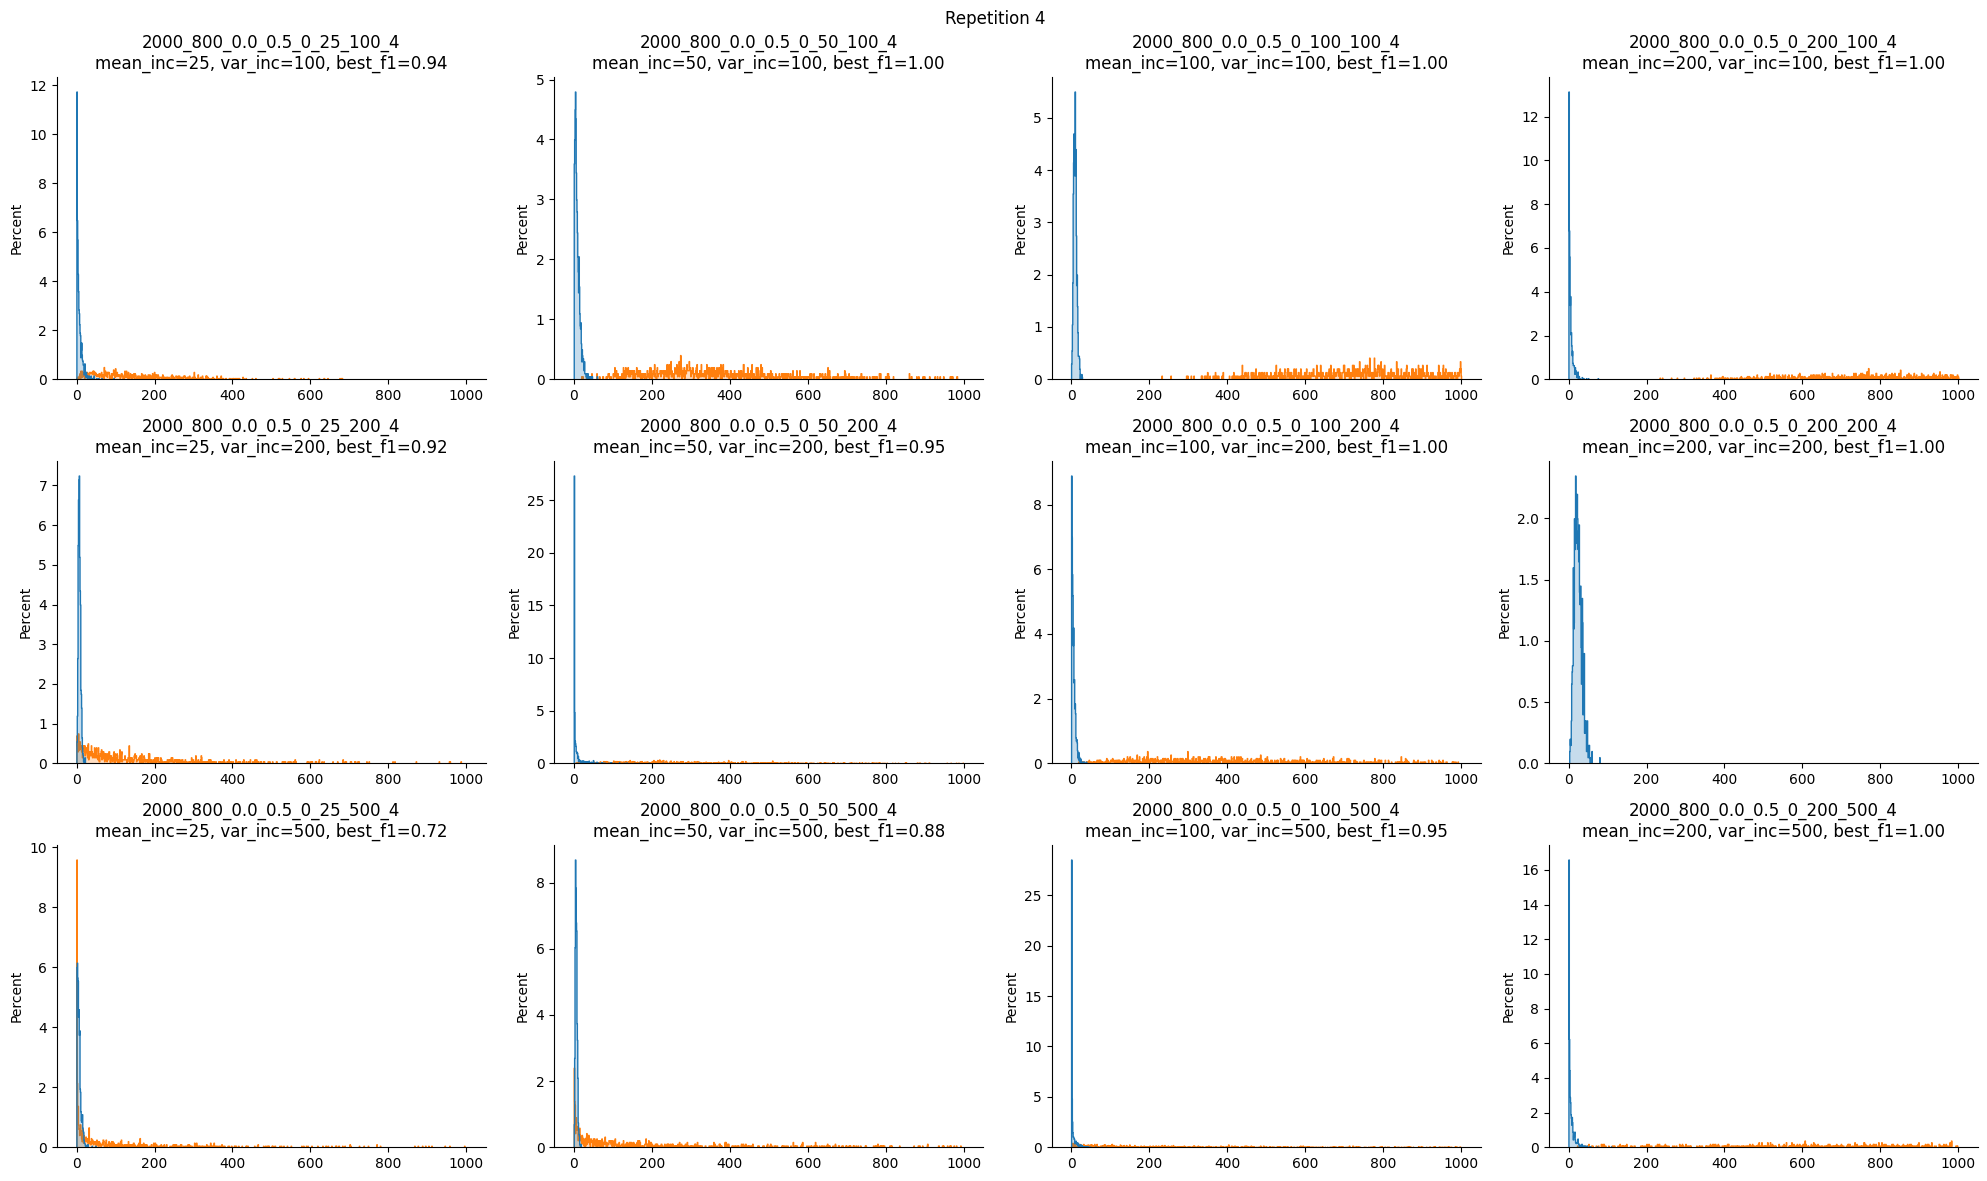

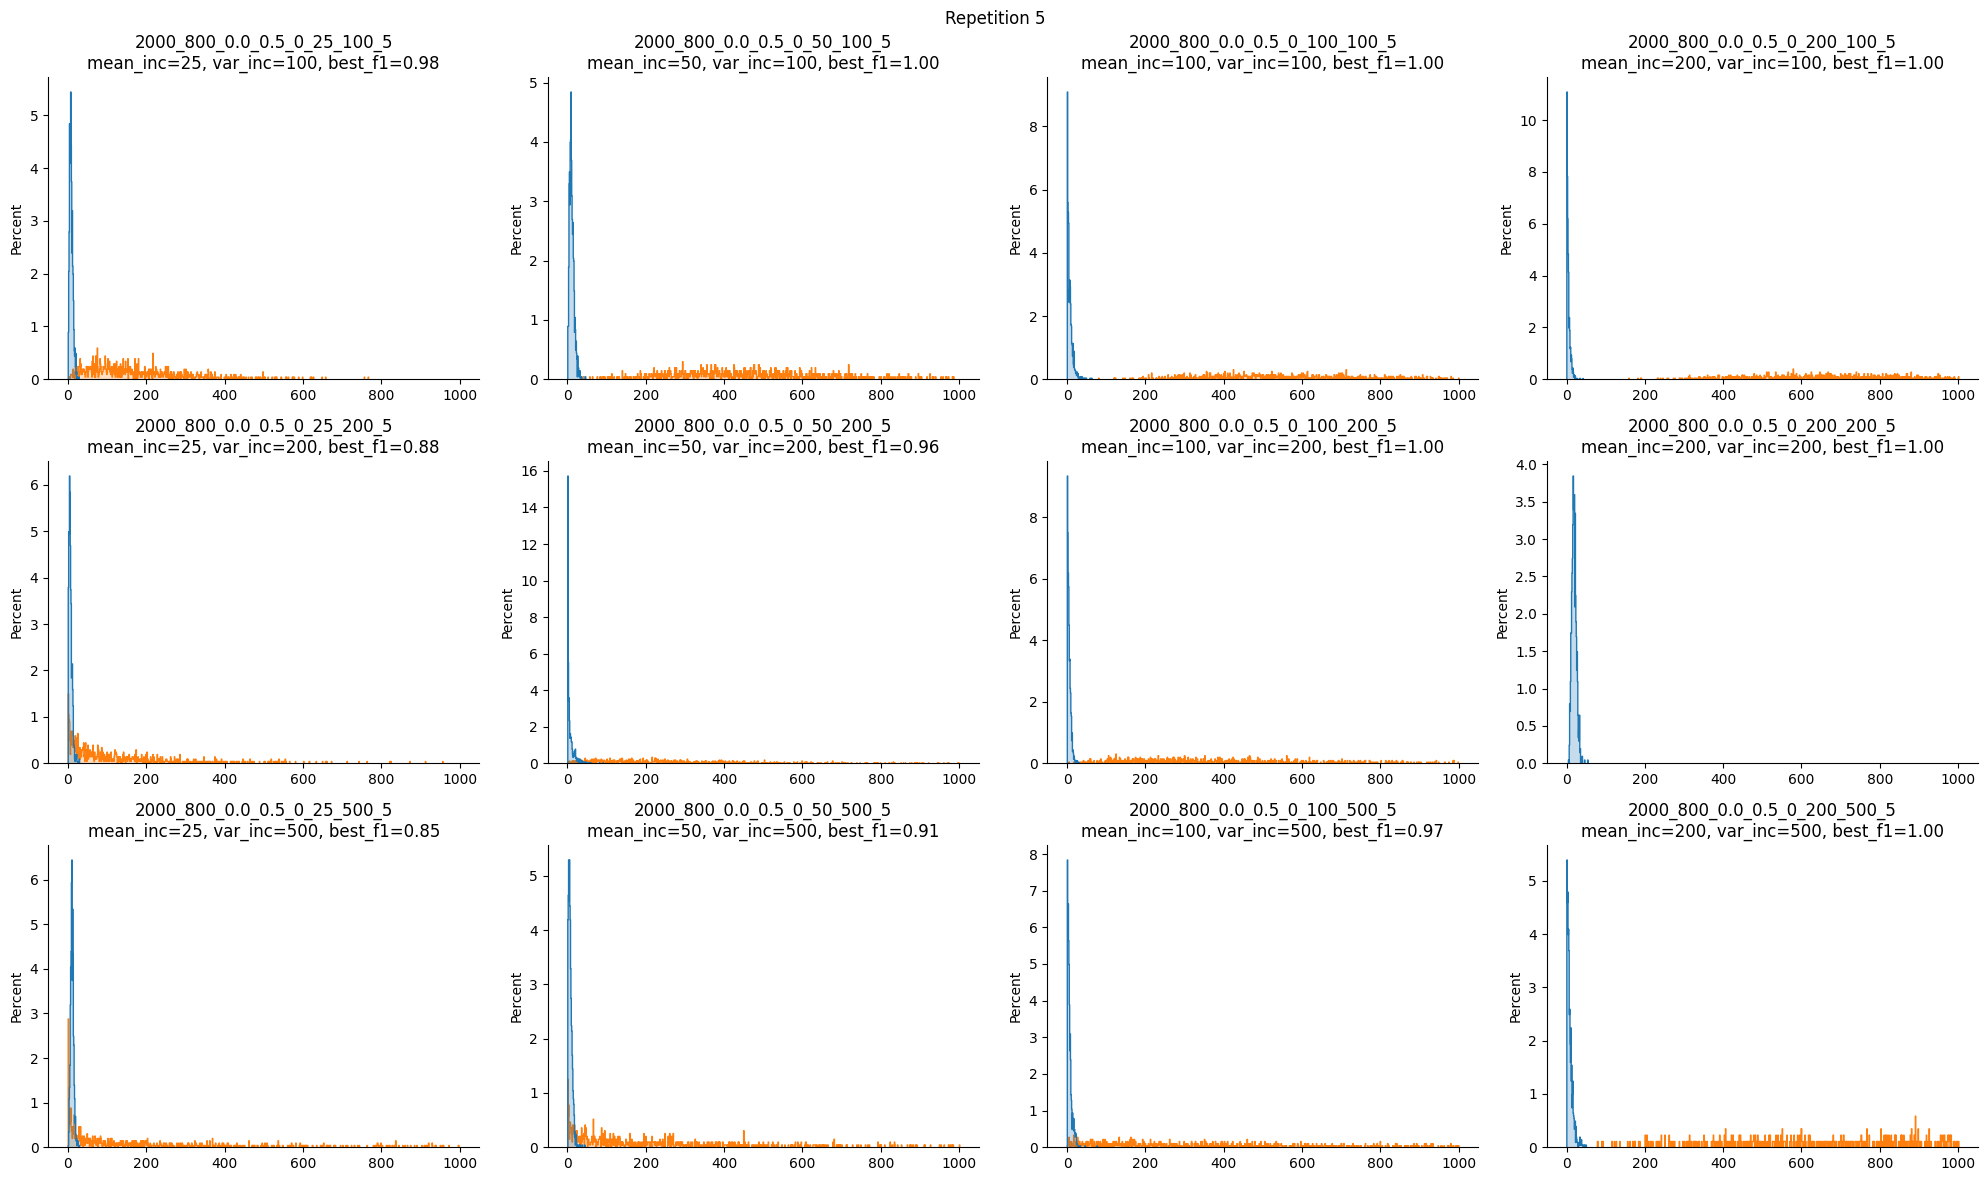

In [17]:
# Original values
# Scenario 1: Signal-to-noise effects
config_scenario_1 = {
    'total_cell': [2000],
    # 'total_cell': [500, 1000, 2000, 5000, 10000, 25000],
    'nclones': [0.4],
    'p_outlier': [0.0],
    'p': [0.5],
    'cov': [0],
    'mean_inc': [25, 50, 100, 200],
    'var_inc': [100, 200, 500],
    'i': [0, 1, 2, 3, 4, 5],
}

import sys
sys.path.append("../../")

from sklearn.model_selection import ParameterGrid
from dextrademixer.utils import DextramerSimulator
import hashlib

params = ParameterGrid(config_scenario_1)[0]
total_cell = params['total_cell']
nclones = int(params['nclones'] * params['total_cell'])
p_outlier = params['p_outlier']
p = params['p']
cov = params['cov']
mean_inc = params['mean_inc']
var_inc = params['var_inc']
reps = params['i']


for rep in config_scenario_1['i']:
    fig = plt.figure(figsize=(5 * len(config_scenario_1['mean_inc']), 4 * len(config_scenario_1['var_inc']), ))
    i = 1
    
    for _, var_inc in enumerate(config_scenario_1['var_inc']):
        for _, mean_inc in enumerate(config_scenario_1['mean_inc']):
            params['mean_inc'] = mean_inc
            params['var_inc'] = var_inc
        
            sim_config = f'{total_cell}_{nclones}_{p_outlier}_{p}_{cov}_{mean_inc}_{var_inc}_{rep}'
            title = f'total_cell={total_cell}_nclones={nclones}_p_outlier={p_outlier}_p={p}_cov={cov}_mean_inc={mean_inc}_var_inc={var_inc}_i={rep}'
            # Use sim_hash to ensure reproducibility, but have variance in seed
            sim_hash = hashlib.sha256(sim_config.encode('utf-8')).digest()
            seed = int.from_bytes(sim_hash[:4], byteorder='little')
        
            
            sim = DextramerSimulator()
        
            mdata1 = sim.simulate_pmhc_data_from_distribution(total_cells=total_cell,
                                                            nof_clones=nclones,
                                                            p_binding_outlier=p_outlier,
                                                            binding_ratio=p,
                                                            mean_inc=mean_inc,
                                                            var_inc=var_inc,
                                                            simulate_neg_control=True,
                                                            use_clonotype_cov=cov,
                                                            plot_data=False,
                                                            rng_key=seed)
            x = mdata1['gex'].X[:, 0]
            x_neg_ctrl = mdata1['gex'][:, 'neg_control'].X
            hue = mdata1['airr'].obs['is_binder']
            x_log = np.log(x + 1)  # Transform to log scale, roughly normal distributed
            zscore = (x_log - x_log.mean()) / x_log.std()
            x_no_outliers = x[zscore < 4]
            hue_no_outliers = hue[zscore < 4]
            outlier_thr = x_no_outliers.max()
    
            # Best theoretical F1
            precision, recall, thresholds = precision_recall_curve(hue, x)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)
            best_idx = np.argmax(f1)
            best_threshold = (thresholds[best_idx] if best_idx < len(thresholds) else scores.max() + 1e-6)
            best_f1 = f1[best_idx]
    
            plt.subplot(len(config_scenario_1['var_inc']), len(config_scenario_1['mean_inc']), i)
            i += 1
        
            # sns.histplot(x=x, stat='percent', element='step', binrange=(0, 100), hue=hue, legend=False, log_scale=False, discrete=True)
            sns.histplot(x=x, stat='percent', element='step', binrange=(0, 1000), hue=hue, legend=False, log_scale=False, discrete=True)
            # sns.histplot(x_neg_ctrl, discrete=True, binrange=(0, 50), stat='percent', element='step', label='neg_ctrl')
            # plt.axvline(best_threshold, c='r', ls=':')
            sns.despine()
            plt.title(f'{sim_config}\nmean_inc={mean_inc}, var_inc={var_inc}, best_f1={best_f1:.2f}')
    plt.suptitle(f'Repetition {rep}')
    plt.tight_layout()
    plt.show()